In [102]:
import numpy as np
import matplotlib.pyplot as plt

Solution to Question 1

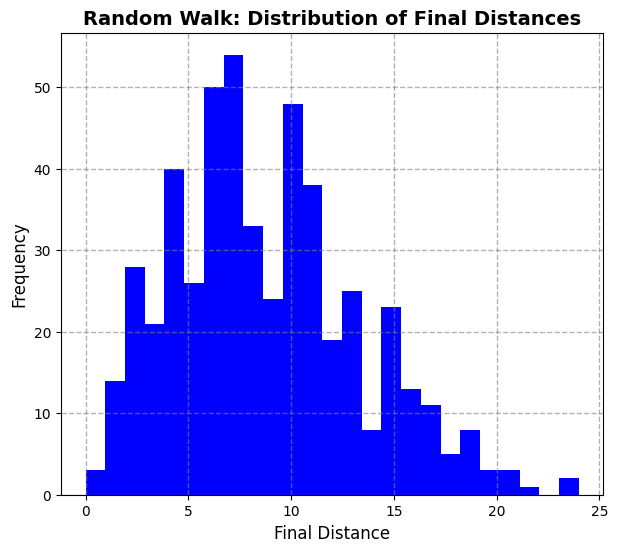



Average r-squared = 97.284 (theoretical value = 100)




In [103]:
# Part a

numOfWalks = 500
numOfSteps = 100

directions = [(1,0), (-1,0), (0,1), (0,-1)]  # Right, Left, Up, Down (initially at origin of a 2D grid facing +y-axis) with equal probabilities of choosing to turn to

final_distances = np.array([])

for walk in range(numOfWalks):
  x, y = 0, 0  # moving to origin at start of each walk
  for step in range(numOfSteps):
    dx, dy = directions[np.random.choice(4)] # since each direction has equal chance of being selected to turn to, we can just randomly select any of it
    x += dx; y += dy  # moving 1 step in the selected direction
  r = np.sqrt(x**2 + y**2)
  final_distances = np.append(final_distances, r)

# Part b

plt.figure(figsize=(7, 6))

plt.hist(final_distances, bins=25, color = 'blue')
plt.title("Random Walk: Distribution of Final Distances", fontsize = 14, fontweight = 'bold')
plt.xlabel("Final Distance", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)
plt.grid(True, lw = 1, ls = '--', color = 'grey', alpha = 0.6)
plt.show()

# Part c

avg_r_squared = np.mean(final_distances**2)
print('\n'+'='*60+'\n')
print(f"Average r-squared = {avg_r_squared} (theoretical value = 100)")
print('\n'+'='*60+'\n')

In a 2D random walk, every step independently influences the total mean squared displacement. For 100 steps, the theoretical value expected is 100. Numerical simulations align with this result because the variance is minimised by averaging across a large sample of independent trials.

Solution to Question 2



Estimated pi = 3.1046 (true value =3.1416, error = 1.176919640312446%




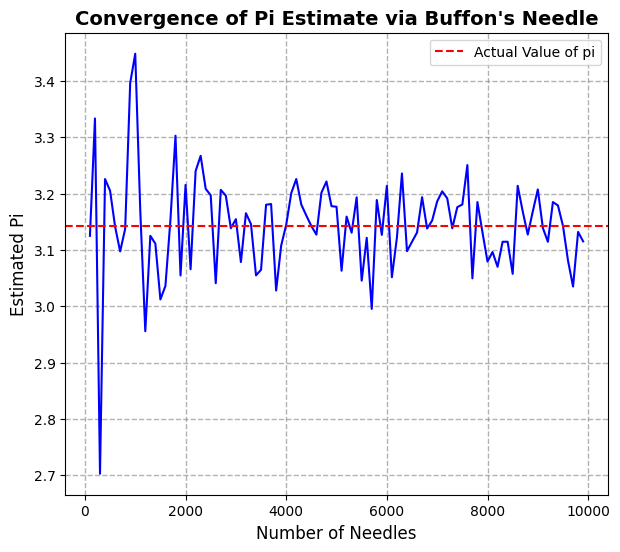

In [107]:
# Part a

N = 10000  # no. of needles
L = 0.5  # length of each needle in some units
# separation between the parallel lines is 1 units

y = np.random.uniform(0, L, N) # generates array of y for each of the N needles
theta = np.random.uniform(0, np.pi, N) # generates array of their thetas

crossings = [1 if y[i] <= 0.25*np.sin(theta[i]) else 0 for i in range(N)] # this condition checks for those needles which satisfy the condition of crossing one of the parallel lines and stores result as 0 (for false condition) or 1 (for true condition)
num_crossings = np.sum(crossings) # gives the number of needles which cross the parallel lines.


# Part b

pi_estimate = 2*N*L/num_crossings
print('\n'+'='*60+'\n')
print(f"Estimated pi = {pi_estimate:.4f} (true value =3.1416, error = {np.abs(3.1416-pi_estimate)*100/3.1416}%")
print('\n'+'='*60+'\n')

# Part c

numOfNeedles = np.arange(100, 10000, 100)
crossingsRunAvg = []

# iterating over various number of needles
for n in numOfNeedles:
  y = np.random.uniform(0, L, n)
  theta = np.random.uniform(0, np.pi, n)

  crossings = [1 if y[i] <= 0.25*np.sin(theta[i]) else 0 for i in range(n)] # this condition checks for those needles which satisfy the condition of crossing one of the parallel lines and stores result as 0 (for false condition) or 1 (for true condition)
  num_crossings = np.sum(crossings)
  pi_estimate = 2*n*L/num_crossings
  crossingsRunAvg.append(pi_estimate)

plt.figure(figsize=(7, 6))
plt.plot(numOfNeedles, crossingsRunAvg, color = 'blue')
plt.axhline(y = np.pi, color = 'red', linestyle = '--', label = 'Actual Value of pi')
plt.title("Convergence of Pi Estimate via Buffon's Needle", fontsize = 14, fontweight = 'bold')
plt.xlabel("Number of Needles", fontsize = 12)
plt.ylabel("Estimated Pi", fontsize = 12)
plt.grid(True, lw = 1, ls = '--', color = 'grey', alpha = 0.6)
plt.legend()
plt.show()

Solution to Question 3

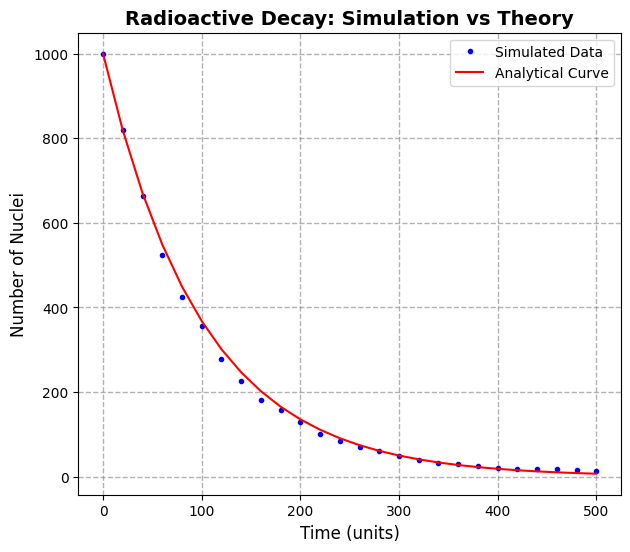



It can be seen in the graph that the simulated values accurately fall on the analytical curve




In [105]:
# Part a

N0 = 1000
lamda = 0.01  # sec^{-1}

U = np.random.uniform(0, 1, N0)
decay_times = -np.log(U)/lamda

# Part b

timeVals = np.arange(0, 501, 20)

remaining_nuclei = []
analytical_N = []

for t in timeVals:
  remaining_nuclei.append(np.sum(decay_times > t))
  analytical_N.append(N0*np.exp(-lamda*t))

#Part c

plt.figure(figsize=(7, 6))
plt.plot(timeVals, remaining_nuclei, '.', color = 'blue', label = 'Simulated Data')
plt.plot(timeVals, analytical_N, color = 'red', label = 'Analytical Curve')
plt.title("Radioactive Decay: Simulation vs Theory", fontsize = 14, fontweight = 'bold')
plt.xlabel("Time (units)", fontsize = 12)
plt.ylabel("Number of Nuclei", fontsize = 12)
plt.legend()
plt.grid(True, lw = 1, ls = '--', color = 'grey', alpha = 0.6)
plt.show()

print('\n'+'='*60+'\n')
print("It can be seen in the graph that the simulated values accurately fall on the analytical curve")
print('\n'+'='*60+'\n')

Solution to Question 4

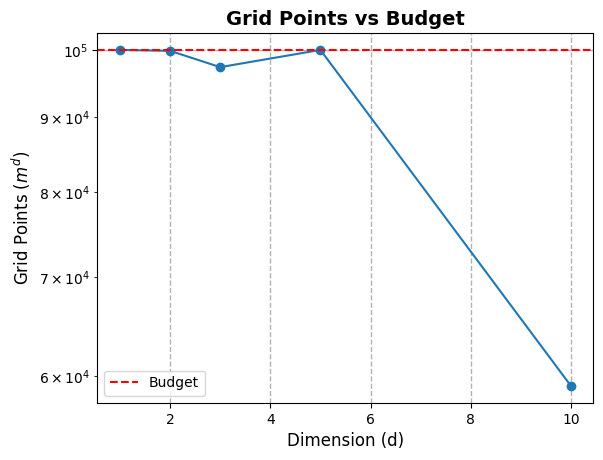

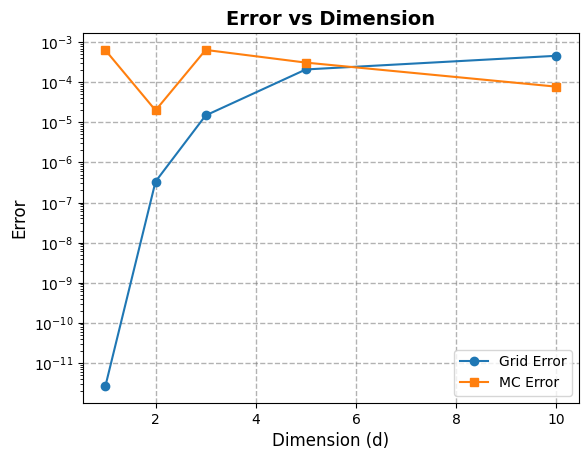

In [108]:
# Part a


N_budget = 100000
dims = [1, 2, 3, 5, 10]

# for grid method
grid_m = []  # number of grid points per dimension
grid_evals = []  # function evaluations for grid method
grid_estimates = [] # estimated integral value from grid method
grid_errors = [] # absolute error for grid method

# for Monte Carlo method
mc_estimates = [] # estimated integral value from Monte Carlo method
mc_errors = [] # absolute error for Monte Carlo method

# Loop through each dimension to perform both integration methods
for d in dims:
  m = np.floor(N_budget**(1/d)) # grid points per dimension
  grid_m.append(m)

  # Total function evaluations for this dimension (m^d)
  evals = m**d
  grid_evals.append(evals)
  axes = [(np.arange(m)+0.5)/m for i in range(d)]
  mesh = np.meshgrid(*axes, indexing='ij')

  # grid method
  X = np.stack(mesh, axis = -1).reshape(-1, d)
  f_grid = np.exp(-np.sum(X, axis = 1)) # functionm at different values
  grid_est = np.mean(f_grid) #averaging the function values
  grid_estimates.append(grid_est)
  grid_errors.append(np.abs(grid_est - ((1 - np.exp(-1))**d)))

  # mote carlo method
  X_mc = np.random.rand(N_budget, d)
  f_mc = np.exp(-np.sum(X_mc, axis = 1)) # function at different values
  mc_est = np.mean(f_mc) # averaging function values
  mc_estimates.append(mc_est)
  mc_errors.append(np.abs(mc_est - ((1 - np.exp(-1))**d)))  # the absolute error for Monte Carlo method

# Part b

plt.semilogy(dims, grid_evals, 'o-')
plt.axhline(N_budget, color = 'red', linestyle = '--', label = 'Budget')
plt.title("Grid Points vs Budget", fontsize = 14, fontweight = 'bold')
plt.xlabel("Dimension (d)", fontsize = 12)
plt.ylabel(r"Grid Points ($m^d$)", fontsize = 12)
plt.legend()
plt.grid(True, lw = 1, ls = '--', color = 'grey', alpha = 0.6)
plt.show()


plt.semilogy(dims, grid_errors, 'o-', label = "Grid Error")
plt.semilogy(dims, mc_errors, 's-', label = "MC Error")
plt.title("Error vs Dimension", fontsize = 14, fontweight = 'bold')
plt.xlabel("Dimension (d)", fontsize = 12)
plt.ylabel("Error", fontsize = 12)
plt.legend()
plt.grid(True, lw = 1, ls = '--', color = 'grey', alpha = 0.6)
plt.show()

Part c

The grid based method fails in high dimensions because the number of required grid points grows exponentially with dimension, making it computationally infeasible (curse of dimensionality). Even with a fixed budget, the grid becomes extremely coarse and inaccurate. Monte Carlo integration, however, samples randomly and its error depends weakly on dimension. As a result, Monte Carlo estimates remain stable even in high-dimension spaces. Practically, this makes monte carlo methods essential for problems in statistical physics, finance and machine learning involving many variables.